# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | To-Do | To-Do |
| Data Processing | To-Do | To-Do |
| Scalability | To-Do | To-Do |
| Pattern Discovery | To-Do | To-Do |
| Computational Requirements | To-Do | To-Do |

**To-Do:** Give one real world problem better suited to traditional ML and one better suited to deep learning. Explain your choices in 2–3 sentences.


**To-Do:** Write a paragraph of 3–5 sentences explaining why deep learning has an advantage in unstructured data processing, using precise terms such as representation learning and hierarchical features.


## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.


**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [11]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [12]:
y = -x**2 + np.random.normal(0, 0.05, len(x))
print("y shape:", y.shape)

y shape: (20,)


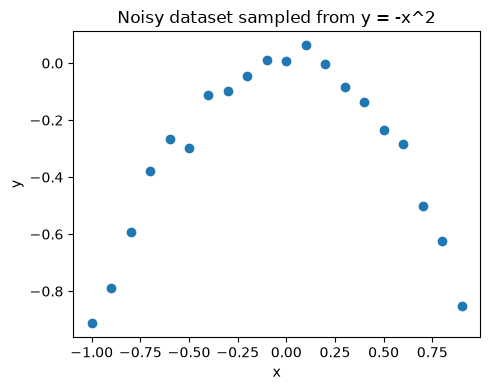

In [13]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [14]:
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [15]:
def polynomial_fit(degree: int):
    # np.polyfit returns coefficients in decreasing power
    coeffs = np.polyfit(x_train, y_train, degree)
    # np.poly1d creates a callable polynomial object
    return np.poly1d(coeffs)

In [16]:
def plot_polyfit(degree: int):
    # 1) fit the polynomial
    poly = polynomial_fit(degree)

    # 2) create a dense linspace over the x range for plotting the curve
    # Use the full range of x to see how the polynomial extends
    x_plot = np.linspace(x.min(), x.max(), 100)

    # 3) evaluate the fitted polynomial on this dense linspace
    y_plot = poly(x_plot)

    # 4) scatter train and test data, and plot the fitted curve
    plt.figure(figsize=(6, 4))
    plt.scatter(x_train, y_train, label='Training Data', color='blue', alpha=0.7)
    plt.scatter(x_test, y_test, label='Test Data', color='red', alpha=0.7)
    plt.plot(x_plot, y_plot, label=f'Polynomial Degree {degree}', color='green', linewidth=2)

    # 5) display
    plt.title(f'Polynomial Fit of Degree {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

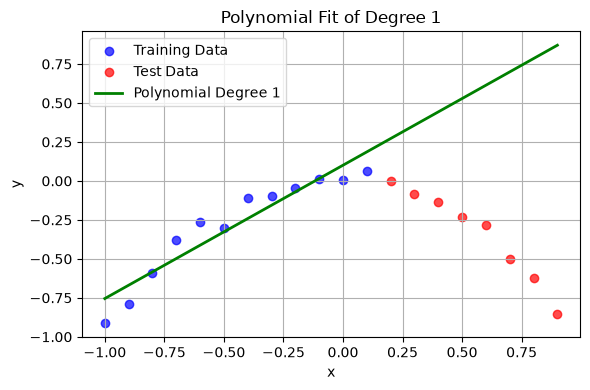

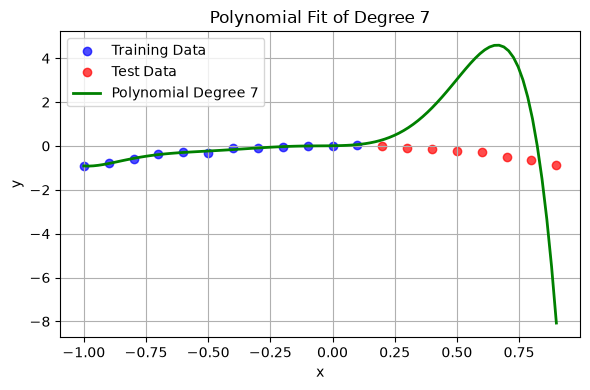

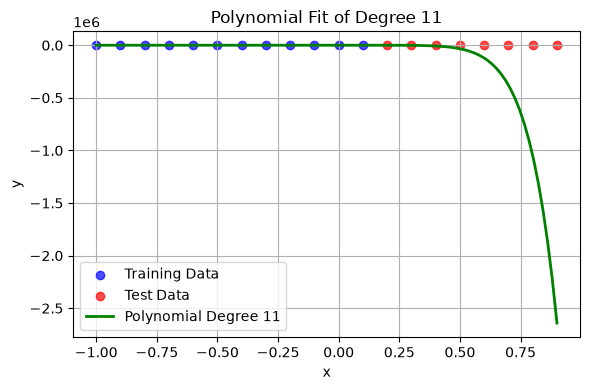

In [17]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)
for d in degrees:
    # fit on train
    poly = polynomial_fit(d)

    # evaluate on train and test
    y_train_pred = poly(x_train)
    y_test_pred = poly(x_test)

    rmse_train = rmse(y_train, y_train_pred)
    rmse_test = rmse(y_test, y_test_pred)

    # append to rows
    rows.append((d, rmse_train, rmse_test))

print(rows[:3])  # peek

[(1, np.float64(0.10022633448647988), np.float64(1.024070883355687)), (2, np.float64(0.04114590494650986), np.float64(0.1257806428238653)), (3, np.float64(0.03733692231108597), np.float64(0.7696519930800754))]


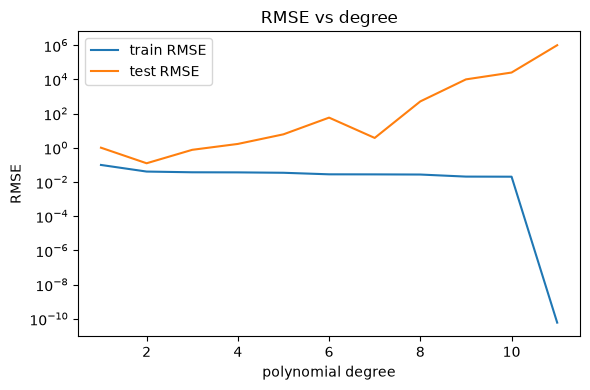

In [19]:
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]

plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()

### Visualisation du Compromis Biais-Variance

Ce graphique illustre le compromis biais-variance. L'erreur d'entraînement (RMSE sur l'ensemble d'entraînement) est un indicateur de la capacité du modèle à s'adapter aux données connues (faible biais). L'erreur de test (RMSE sur l'ensemble de test) mesure la capacité de généralisation du modèle, englobant à la fois le biais et la variance.

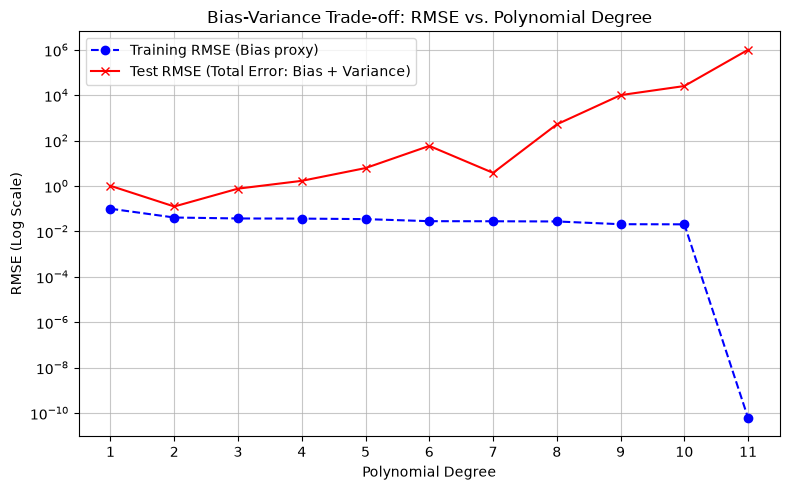

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(degs, rmse_tr, label='Training RMSE (Bias proxy)', marker='o', linestyle='--', color='blue')
plt.plot(degs, rmse_te, label='Test RMSE (Total Error: Bias + Variance)', marker='x', linestyle='-', color='red')
plt.yscale("log")
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Log Scale)')
plt.title('Bias-Variance Trade-off: RMSE vs. Polynomial Degree')
plt.xticks(degs)
plt.grid(True, which="both", ls="-", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Dans ce graphique:

*   **Faibles degrés (ex: Degré 1) :** La RMSE d'entraînement et de test est élevée. C'est le **biais élevé** (sous-apprentissage), car le modèle est trop simple pour capturer la vraie relation des données.
*   **Degré Optimal (ex: Degré 2) :** La RMSE de test est minimisée. Le modèle a un bon équilibre entre biais et variance, s'ajustant bien aux données sans surapprendre le bruit.
*   **Degrés Élevés (ex: Degrés 7-11) :** La RMSE d'entraînement diminue, mais la RMSE de test augmente considérablement. C'est la **variance élevée** (surapprentissage), où le modèle s'adapte trop au bruit des données d'entraînement et généralise mal aux nouvelles données.

**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.